In [53]:
#new Dataset
#update output folder if required

output_folder_name = 'qg_by_(qg+qs)_using_first_three_imp_locals'

import time
overall_start_time = time.time()
import os

import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
# from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
# ds = dataset_init.ds_init_3d(myJob, chunks={}) 
ds = dataset_init.ds_init(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2026 Apr 02 17:46:25 > Log nicely initialized 
2026 Apr 02 17:46:25 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Apr 02 17:46:25 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003
2026 Apr 02 17:46:25 > (DI0021) Found 35 time-varying files in date range
2026 Apr 02 17:46:25 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003/pod0003_atm_vgrid_ml.nc
2026 Apr 02 17:46:25 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Apr 02 17:46:25 > (DI0024) Dimensions in vgrid: {'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60}
2026 Apr 02 17:46:25 > (DI0037) Loading horizontal grid data from /pool/data/ICON/gr

In [ ]:
#Functions

#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

#Weighted R2 score
def weighted_r_squared(y_true, y_pred, weight):
    mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_true)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)
    r2_score = 1 - (ss_residual / ss_total)
    return r2_score


In [55]:
#Data Pre-processing

#subset of the original dataset

seed = 1
sample_frac = 0.001

ht=31
data=ds.sel(height=ht, height_2=ht) 

total = data['clw'] + data['cli']
data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
# for ht in range(32, 91, 5): #(32, 91, 5)
for ht in range(36, 91, 5): #(32, 91, 5)
    data = ds.sel(height=ht, height_2=ht)

    total = data['clw'] + data['cli']
    data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
    data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
    dfs.append(df_sampled) 
    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)


prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))

#threshold

threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

if df_new.empty:
    df_new = df

df = df_new


#RH data

df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])

count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("out-of-range count = ", count)
print("out-of-range count percent = ", 100*count/len(df['RH']), " %")

df['RH']= df['RH'].clip(lower=0, upper=100)

#Insert variables to the df
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 15th position
#df.pop('hus')

df['clw+cli']=df['clw']+df['cli']
col=df.pop('clw+cli')
df.insert(26, 'clw+cli', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['cllvi+clivi']=df['cllvi']+df['clivi']
col=df.pop('cllvi+clivi')
df.insert(27, 'cllvi+clivi', col) 

# df['m_ci']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli'])

# col=df.pop('m_ci')
# df.insert(28, 'm_ci', col) 

#mass-weighted random sampling

df['m_rsg']=df['dzghalf']*df['rho']*df['cell_area']* (df['qr']+df['qs']+df['qg'])

col=df.pop('m_rsg')
df.insert(28, 'm_rsg', col) 

df = df.sort_values(by='m_rsg', ascending=False)
df = df.reset_index(drop=True)

total_mass = df['m_rsg'].sum()

df['cum_mass'] = df['m_rsg'].cumsum()

col=df.pop('cum_mass')
df.insert(29, 'cum_mass', col) 

#Adding another column; qr+qg+qs and use it later as an input feature

df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(30, 'qr+qg+qs', col)

#mass-weighted random sampling (continued)
n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)

random_values = np.random.uniform(0, total_mass, size=n_samples)

print('Random values: ', random_values)

indices= np.searchsorted(df['cum_mass'].values, random_values)

df_orig=df

df = df.iloc[indices].reset_index(drop=True)

#OBtain lon and lat from clon and clat respectively
df['lon'] = df['clon']*180/np.pi #in degrees
df['lat'] = df['clat']*180/np.pi #in degrees


Last value of clon in df with height 36 is 1.3343108942333097
Last value of clon in df with height 41 is 1.3343108942333097
Last value of clon in df with height 46 is 1.3343108942333097
Last value of clon in df with height 51 is 1.3343108942333097
Last value of clon in df with height 56 is 1.3343108942333097
Last value of clon in df with height 61 is 1.3343108942333097
Last value of clon in df with height 66 is 1.3343108942333097
Last value of clon in df with height 71 is 1.3343108942333097
Last value of clon in df with height 76 is 1.3343108942333097
Last value of clon in df with height 81 is 1.3343108942333097
Last value of clon in df with height 86 is 1.3343108942333097
Expected length of df:  251658240
Final length of df:  251658240
out-of-range count =  571480
out-of-range count percent =  0.9012190553676325  %
Random values:  [5.14901517e+12 1.69837126e+12 4.36693364e+11 ... 5.91907374e+12
 4.70679822e+12 3.47603666e+12]


In [56]:
df['qg/(qs+qg)'] = df['qg'] / (df['qs']+ df['qg']) 
print('Number of NaN values in qg/(qs+qg) column: ', df['qg/(qs+qg)'].isna().sum())
df = df.dropna(subset=['qg/(qs+qg)'])
print('Number of NaN values in qg/(qs+qg) column now: ', df['qg/(qs+qg)'].isna().sum())

Number of NaN values in qg/(qs+qg) column:  5
Number of NaN values in qg/(qs+qg) column now:  0


In [57]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'zg', 'ua', 'va', 'pfull', 'height', 'clw+cli',
       'cllvi+clivi', 'm_rsg', 'cum_mass', 'qr+qg+qs', 'height_2',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)', 'lon', 'lat', 'qg/(qs+qg)'],
      dtype='str')

In [58]:
#Select ft's
feature_names= ['ta','clw+cli','RH'] 

In [59]:

X = df[feature_names] #X is a df 
y = df['qg/(qs+qg)'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


Training- Elapsed time: 0.2723 minutes


ta: 46.1461 %
clw+cli: 37.3316 %
RH: 16.5223 %


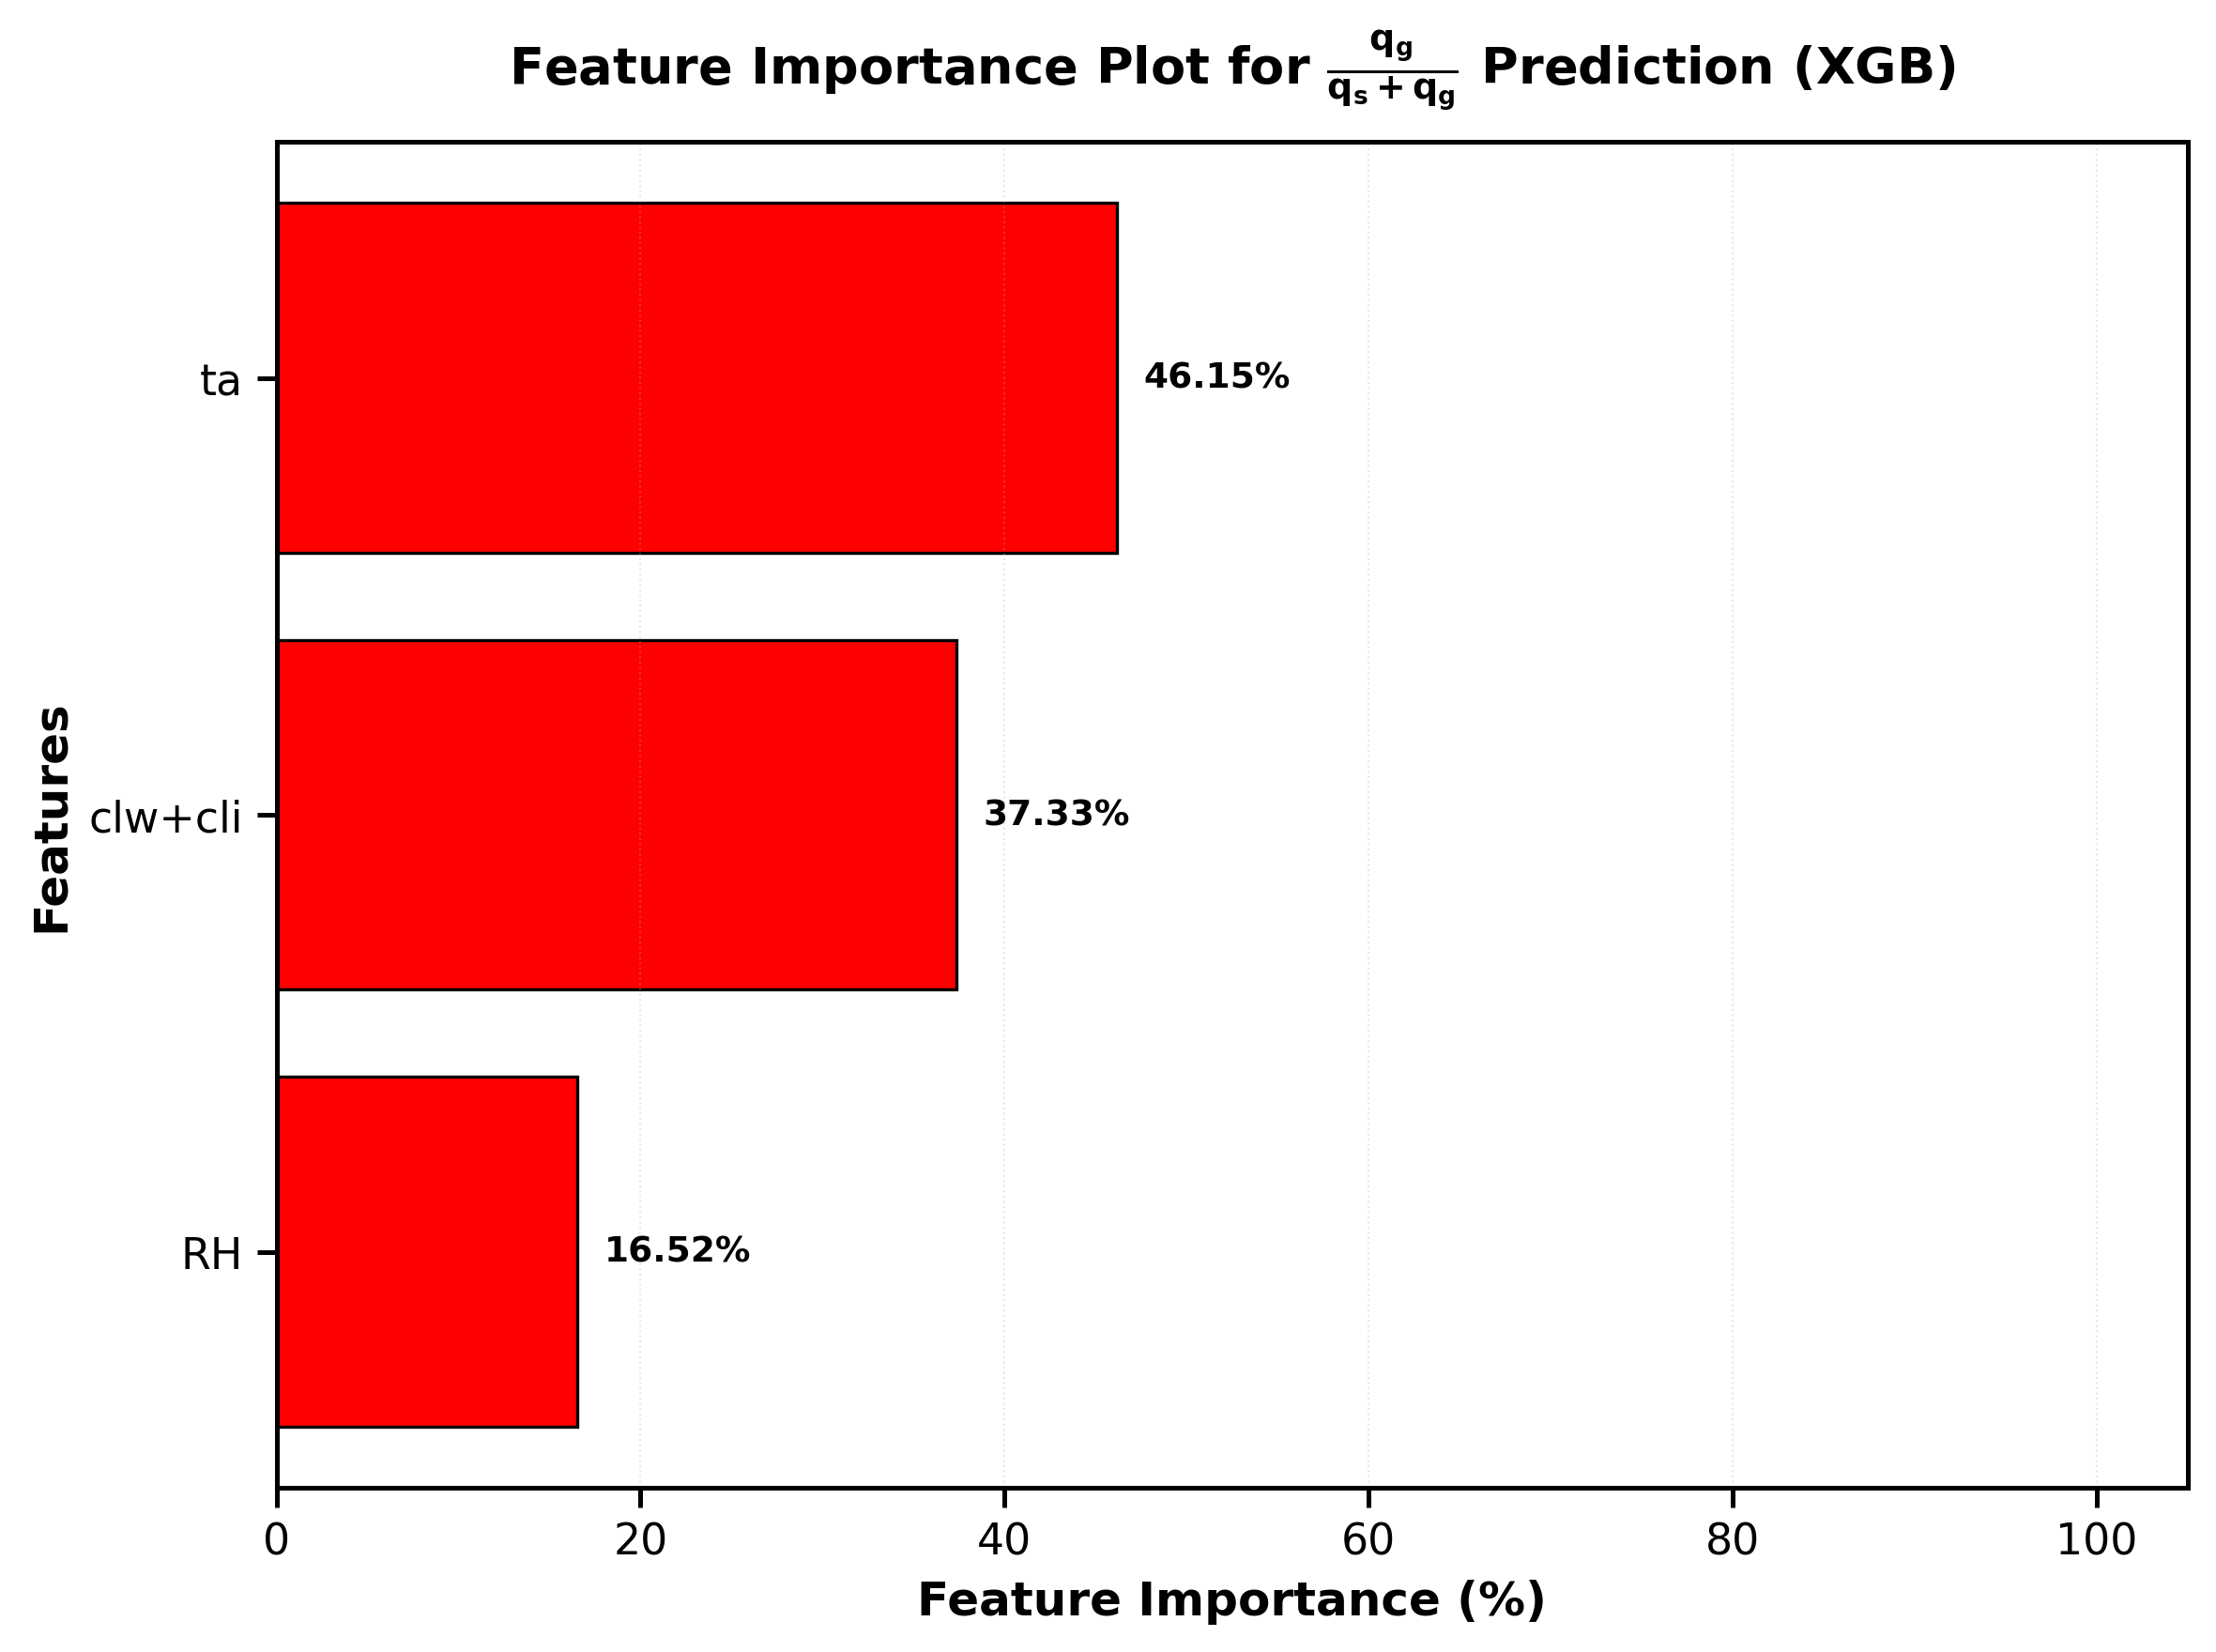

In [60]:
#Feature importance plot
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(r"Feature Importance Plot for $\mathbf{\frac{q_g}{q_s + q_g}}$ Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.savefig(f"output/{output_folder_name}/FeatureImportance.png",
    dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


Prediction- Elapsed time: 0.0014 minutes
max value of the fraction:  1.041421
min value of the fraction:  -0.19688392
Out-of-range count =  231
Out-of-range count percent =  0.01821426121458371  %
MSE_Test:  0.04909089
RMSE_TEST: 0.2215646356344223
mae_TEST: 0.1447751224040985
R² score:  0.4575667381286621


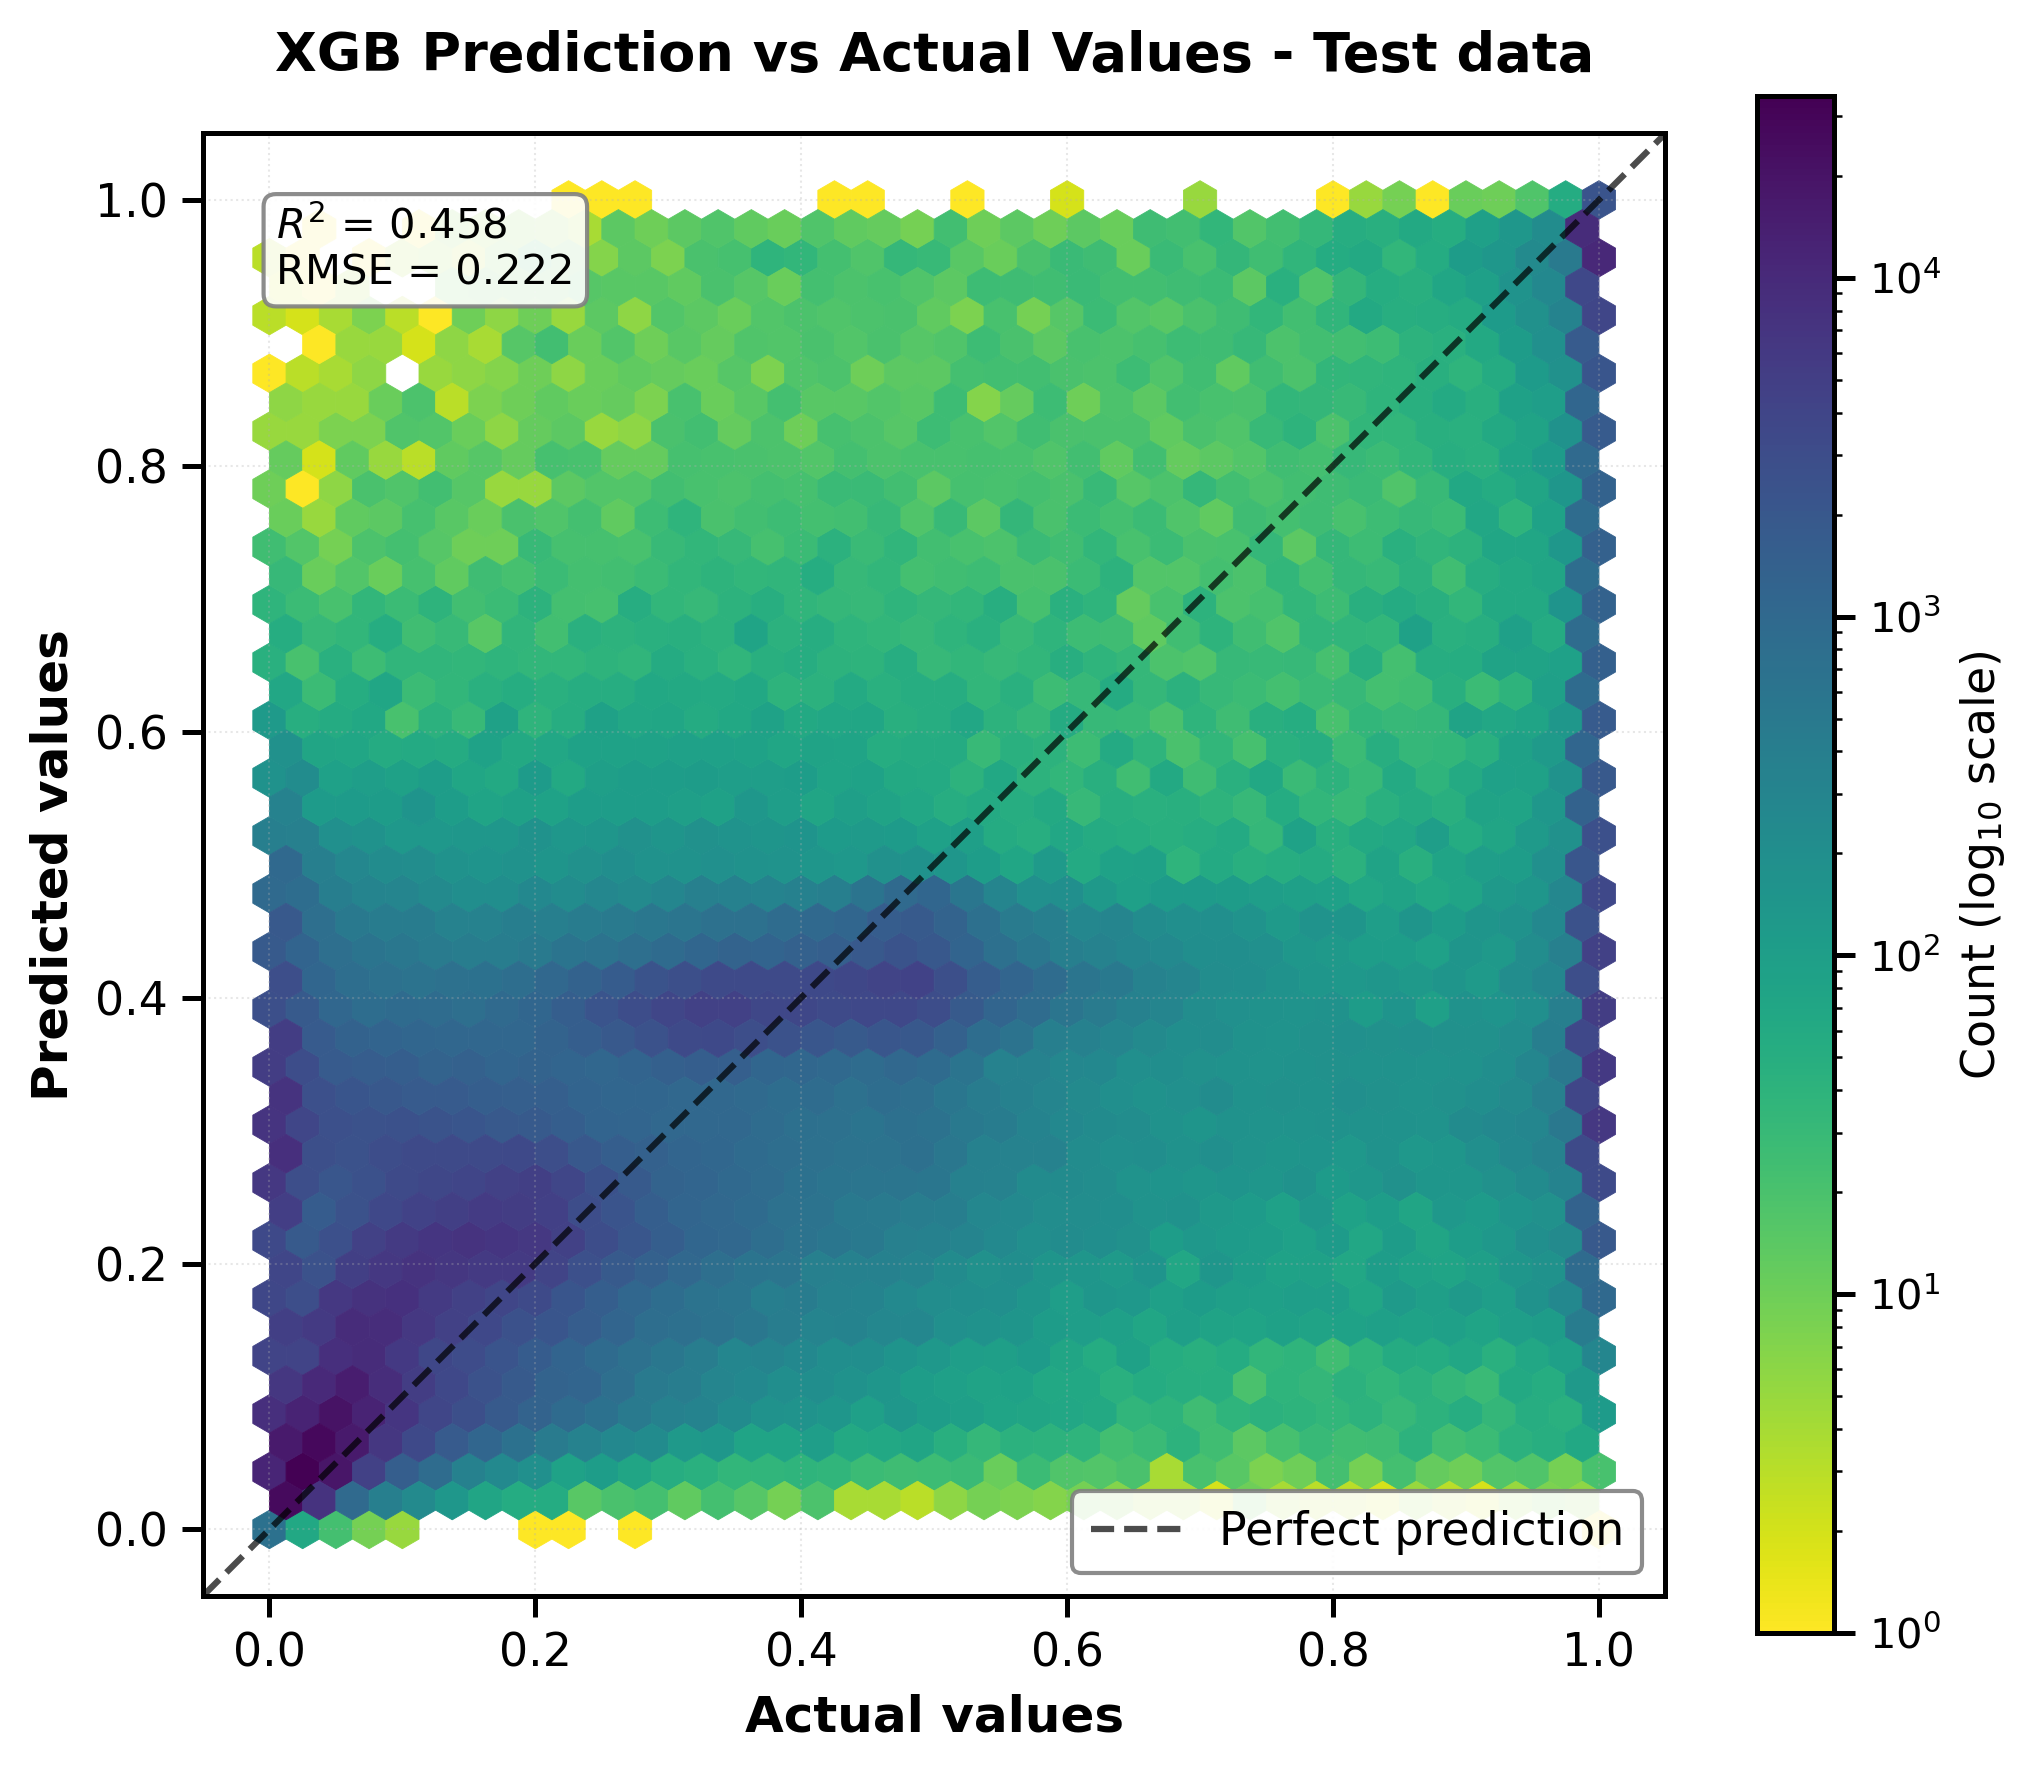

In [ ]:
#Prediction

prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

y_pred = np.clip(y_pred, 0, 1)
# y_test=y_test.ravel()
# y_pred=y_pred.ravel()

#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

#weighted_R2_test
df_test= df.loc[X_test.index]
weight = df_test['cell_area']*df_test['dzghalf']*df_test['rho']*( df_test['qs'] + df_test['qg'] ) 

weighted_r2 = weighted_r_squared(y_test, y_pred, weight)
print("Weighted R² score: ", weighted_r2)

#Plotting predicted vs actual values
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

#Create hexbin plot with reversed colormap (light to dark)
#Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
hb = ax.hexbin(
    # y_test.flatten(), 
    # y_test.values, 
    y_test, 
    y_pred.flatten(), 
    gridsize=40,
    cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
    bins='log',
    mincnt=1,
    linewidths=0.2,
    edgecolors='face'
)

#Add colorbar with proper formatting
cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
cbar.ax.tick_params(labelsize=10)

#Calculate axis limits with padding
data_min = min(y_test.min(), y_pred.min())
data_max = max(y_test.max(), y_pred.max())
padding = (data_max - data_min) * 0.05
ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

#Perfect prediction line
ax.plot(
    [data_min - padding, data_max + padding],
    [data_min - padding, data_max + padding],
    'k--',  # Black dashed line
    lw=1.5,
    alpha=0.7,
    label='Perfect prediction',
    zorder=3
)

#Add statistics text box
# textstr = f'$R^2$ = {r2_sklearn:.3f}\nModified $R^2$ = {modified_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
textstr = f'$R^2$ = {r2_sklearn:.3f}\nRMSE = {rmse_TEST:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)


ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
ax.set_title('XGB Prediction vs Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

#Make axes equal and square
ax.set_aspect('equal', adjustable='box')

ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

plt.tight_layout()
# plt.show()

